In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('data/stud.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.shape

(1000, 8)

In [4]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [6]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [7]:
#  no missing values

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# No duplicates

In [10]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [11]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [12]:
print("Categories in 'gender' variable :  ",end= " ")
print(df['gender'].unique())
print("\n")

print("Categories in 'race/ethnicity' variable :  ", end = " ")
print(df['race/ethnicity'].unique())
print("\n")

print("Categories in 'parental level of education ' variable :  ", end = " ")
print(df['parental level of education'].unique())
print("\n")

print("Categories in 'lunch' variable :  ", end = " ")
print(df['lunch'].unique())
print("\n")

print("Categories in 'test preparation course' variable :  ", end = " ")
print(df['test preparation course'].unique())
print("\n")

Categories in 'gender' variable :   <StringArray>
['female', 'male']
Length: 2, dtype: str


Categories in 'race/ethnicity' variable :   <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str


Categories in 'parental level of education ' variable :   <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str


Categories in 'lunch' variable :   <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str


Categories in 'test preparation course' variable :   <StringArray>
['none', 'completed']
Length: 2, dtype: str




In [13]:
numerical_features = list(df.select_dtypes(include = ['number']).columns)

categorical_features = list(df.select_dtypes(include = ['object']).columns)

print(" Numerical Features : ", numerical_features )
print("Categorical Features : ", categorical_features)

 Numerical Features :  ['math score', 'reading score', 'writing score']
Categorical Features :  ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [14]:
# adding columns for total score and average
df['total score' ] = df['math score'] + df['reading score'] + df['writing score']
df['average' ] = df['total score'] / 3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [15]:
reading_full = df[df['reading score'] == 100]['average'].count()
writing_full = df[df['writing score'] == 100]['average'].count()
math_full = df[df['math score'] == 100]['average'].count()

print(f"The number of students with full marks in reading : {reading_full}")
print(f"The number of students with full marks in math : {math_full}")
print(f"The number of students with full marks in writing : {writing_full}")

The number of students with full marks in reading : 17
The number of students with full marks in math : 7
The number of students with full marks in writing : 14


In [16]:
reading_less_20 = df[df['reading score'] <= 20]['average'].count()
writing_less_20 = df[df['writing score'] <= 20]['average'].count()
math_less_20 = df[df['math score'] <= 20]['average'].count()

print(f"The number of students with marks less than 20 in reading : {reading_less_20}")
print(f"The number of students with marks less than 20 in math : {math_less_20}")
print(f"The number of students with marks less than 20 in writing : {writing_less_20}")

The number of students with marks less than 20 in reading : 1
The number of students with marks less than 20 in math : 4
The number of students with marks less than 20 in writing : 3


<Axes: xlabel='average', ylabel='Count'>

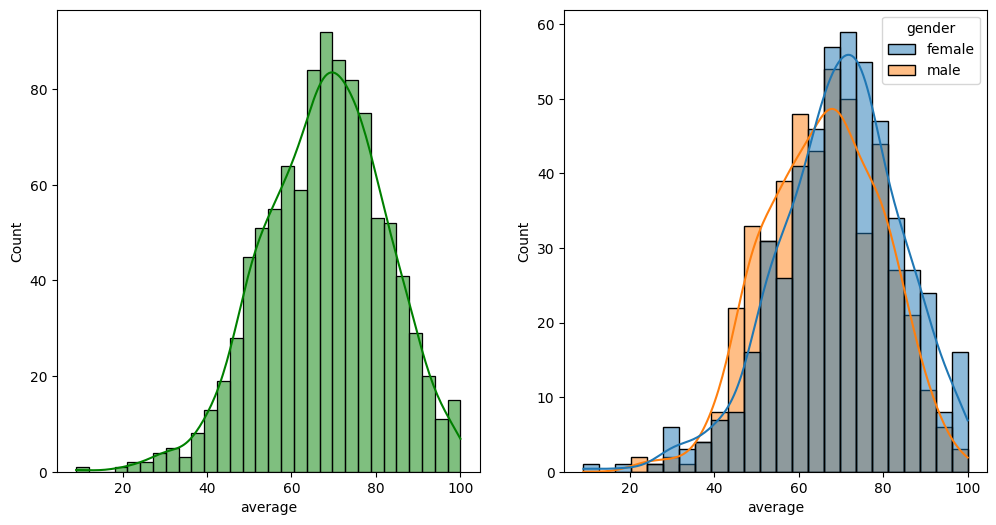

In [21]:
# Visualization
fig, axs = plt.subplots(1,2,figsize = (12,6))
plt.subplot(1,2,1)
sns.histplot(data = df,  x  = 'average', bins= 30 , kde = True, color = 'g')
plt.subplot(1,2,2)
sns.histplot(data = df,x = 'average', kde = True, hue = 'gender')


<Axes: xlabel='total score', ylabel='Count'>

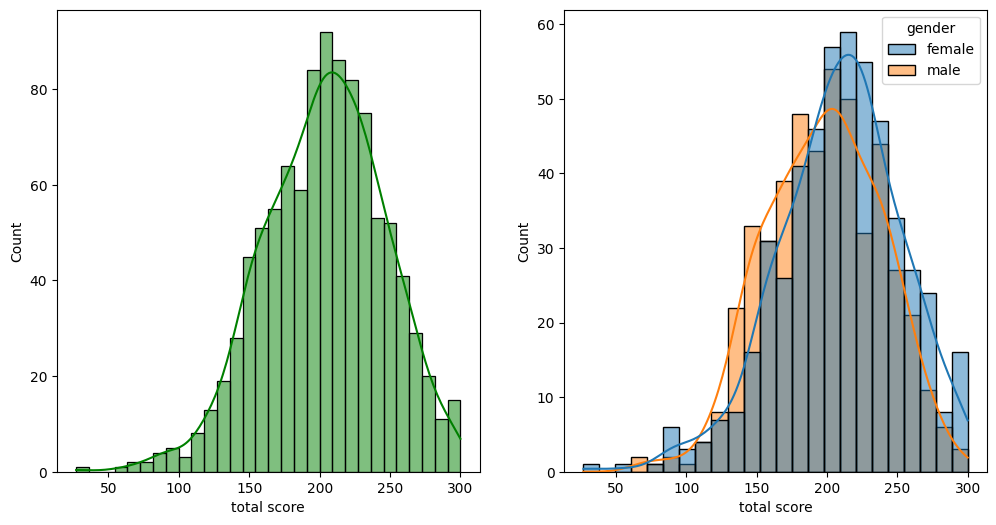

In [22]:
fig, axs = plt.subplots(1,2,figsize = (12,6))
plt.subplot(1,2,1)
sns.histplot(data = df,  x  = 'total score', bins= 30 , kde = True, color = 'g')
plt.subplot(1,2,2)
sns.histplot(data = df,x = 'total score', kde = True, hue = 'gender')


In [23]:
# Females outperform males in total and average score   

<Axes: xlabel='average', ylabel='Count'>

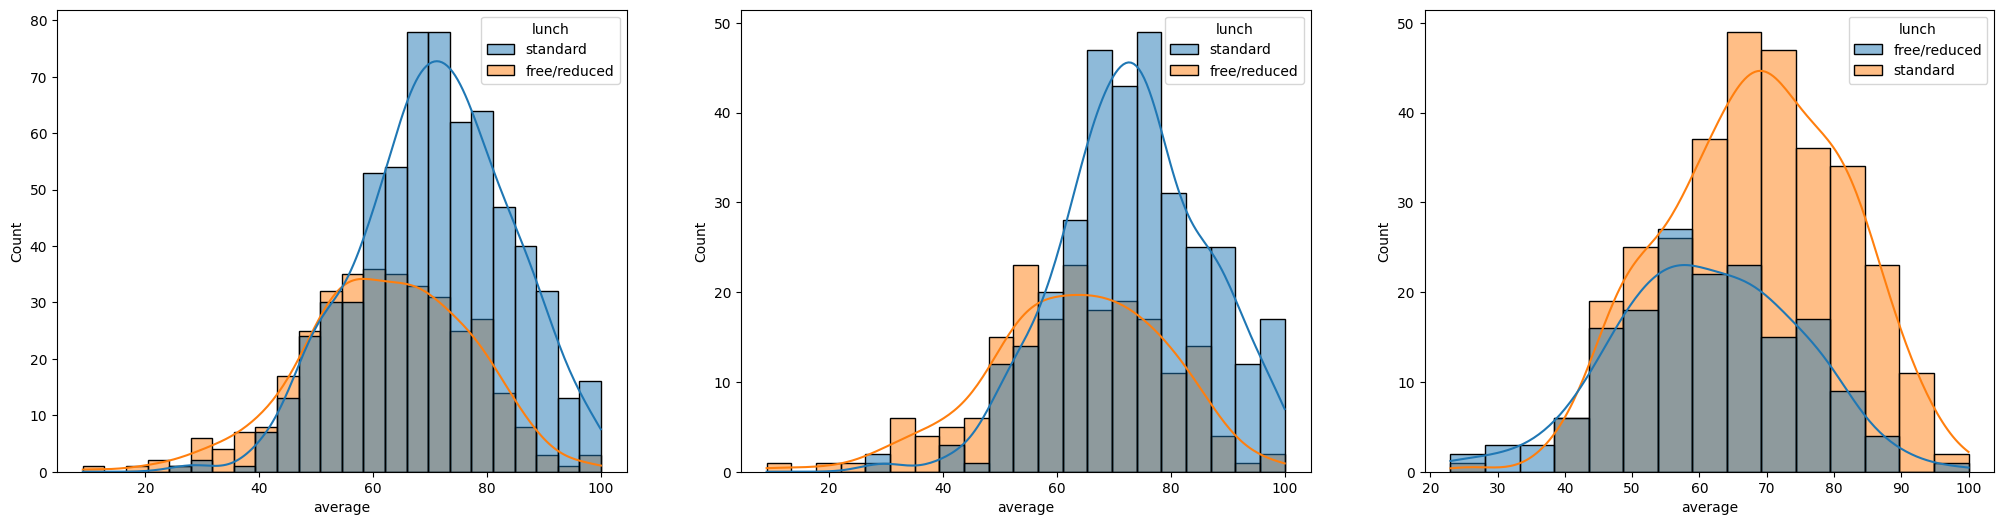

In [26]:
plt.subplots(1,3,figsize = (25,6))
plt.subplot(1,3,1)
sns.histplot(data = df , x = 'average', kde = True, hue = 'lunch')
plt.subplot(1,3,2)
sns.histplot(data = df [df.gender =='female'] , x = 'average',kde = True, hue='lunch')
plt.subplot(1,3,3)
sns.histplot(data = df[df.gender == 'male' ], x = 'average', kde = True, hue = 'lunch')

<Axes: xlabel='average', ylabel='Count'>

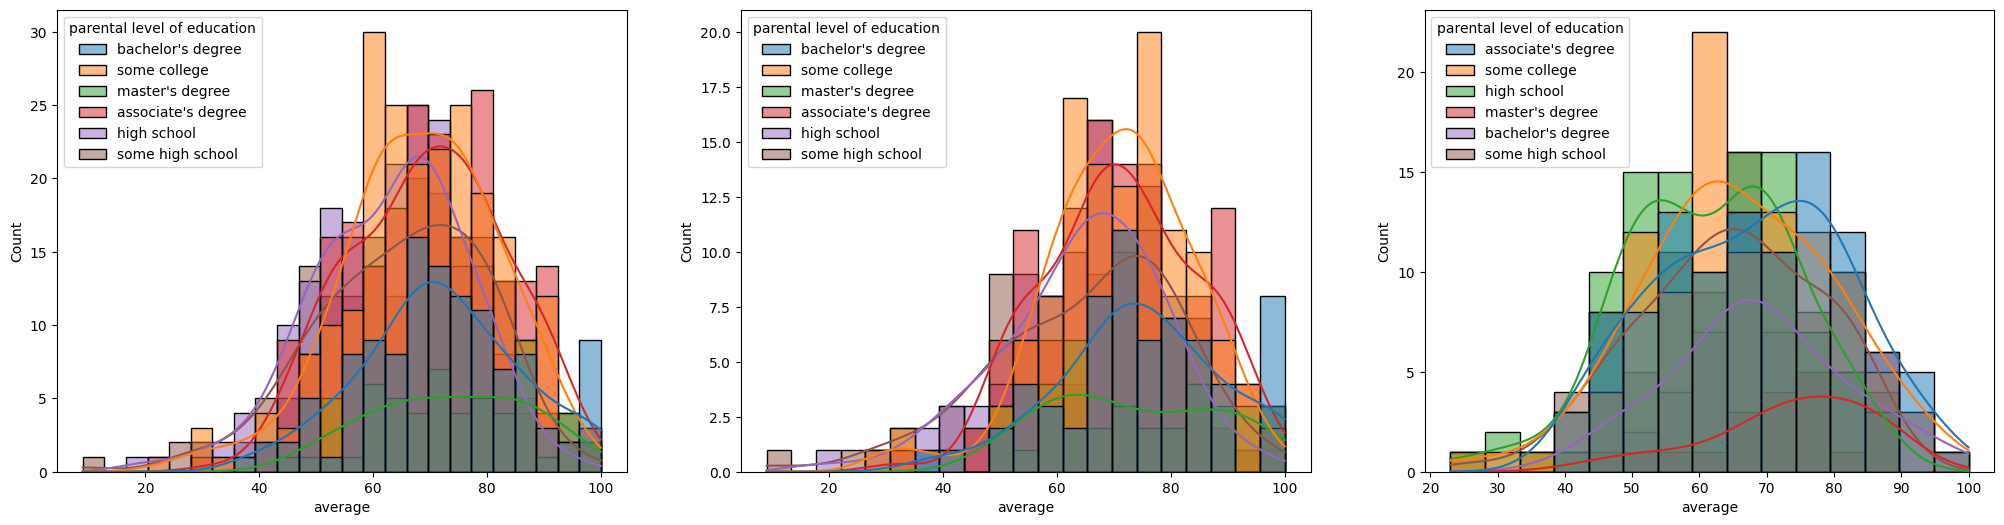

In [27]:
plt.subplots(1,3,figsize = (25,6))
plt.subplot(1,3,1)
sns.histplot(data = df , x = 'average', kde = True, hue = 'parental level of education')
plt.subplot(1,3,2)
sns.histplot(data = df [df.gender =='female'] , x = 'average',kde = True, hue='parental level of education')
plt.subplot(1,3,3)
sns.histplot(data = df[df.gender == 'male' ], x = 'average', kde = True, hue = 'parental level of education')

<Axes: xlabel='average', ylabel='Count'>

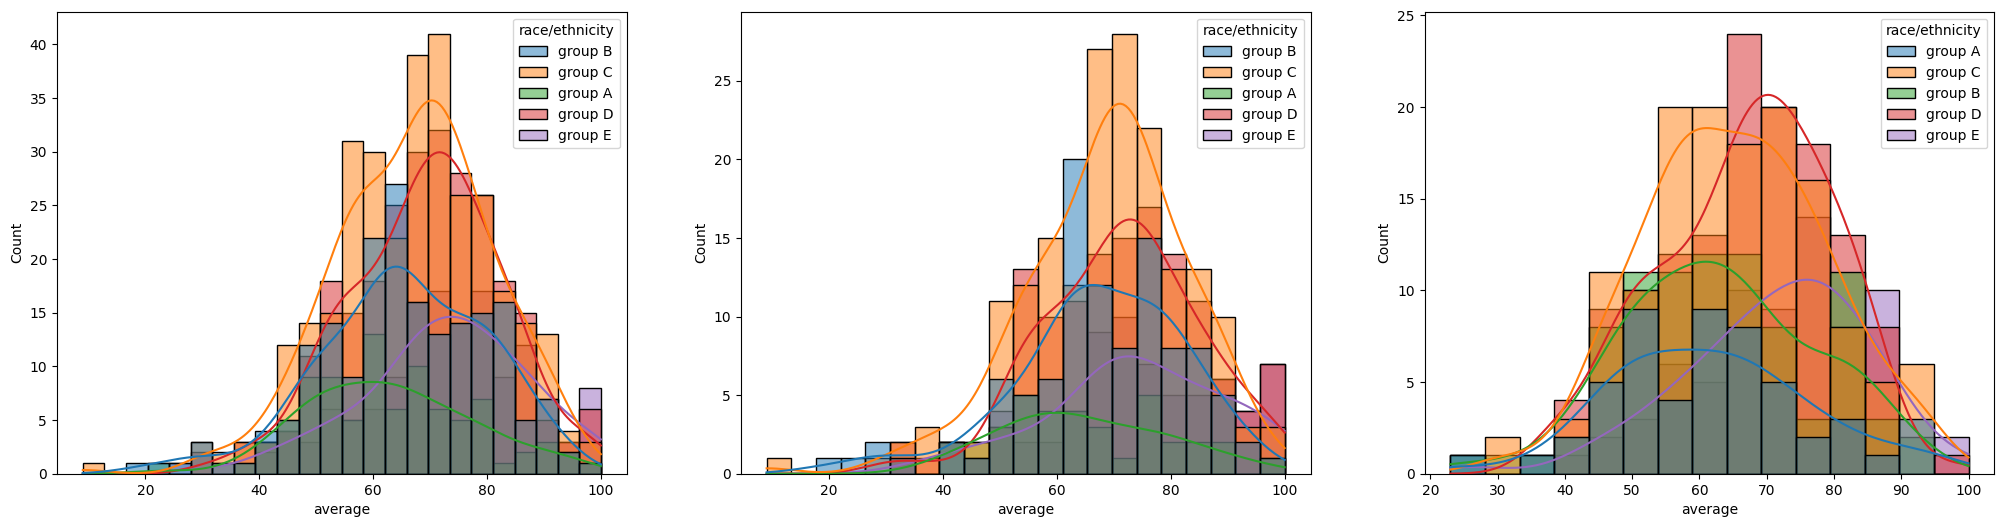

In [28]:
plt.subplots(1,3,figsize = (25,6))
plt.subplot(1,3,1)
sns.histplot(data = df , x = 'average', kde = True, hue = 'race/ethnicity')
plt.subplot(1,3,2)
sns.histplot(data = df [df.gender =='female'] , x = 'average',kde = True, hue='race/ethnicity')
plt.subplot(1,3,3)
sns.histplot(data = df[df.gender == 'male' ], x = 'average', kde = True, hue = 'race/ethnicity')

<Axes: title={'center': 'Writing Scores : '}, ylabel='writing score'>

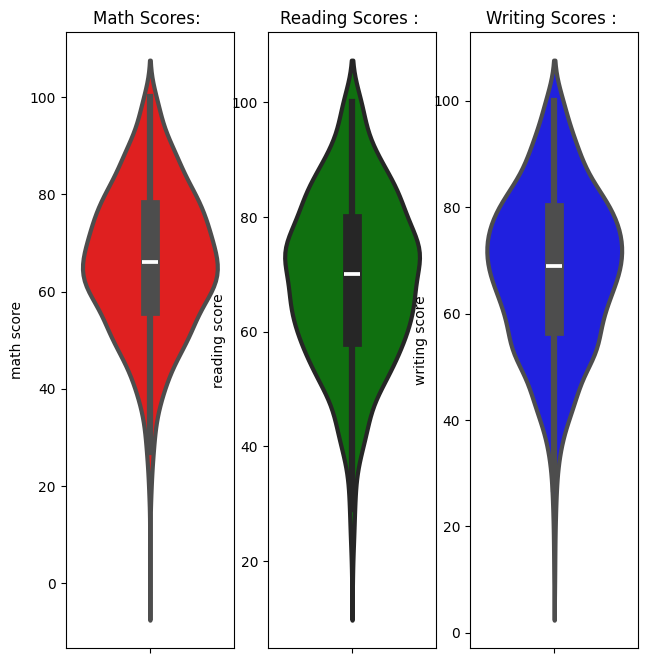

In [29]:
# Max score of students in all three subjects

plt.figure(figsize = (10,8))

plt.subplot(1,4,1)
plt.title("Math Scores: ")
sns.violinplot(y = 'math score', data = df, color = 'red' , linewidth = 3)

plt.subplot(1,4,2)
plt.title("Reading Scores : ")
sns.violinplot(y = 'reading score',data = df , color = 'green', linewidth = 3)
plt.subplot(1,4,3)

plt.subplot(1,4,3)
plt.title("Writing Scores : ")
sns.violinplot(y = 'writing score',data = df , color = 'blue', linewidth = 3)
plt.subplot(1,4,3)

In [38]:
df['parental level of education'].unique()

<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str

(np.float64(-1.25), np.float64(1.25), np.float64(-1.25), np.float64(1.25))

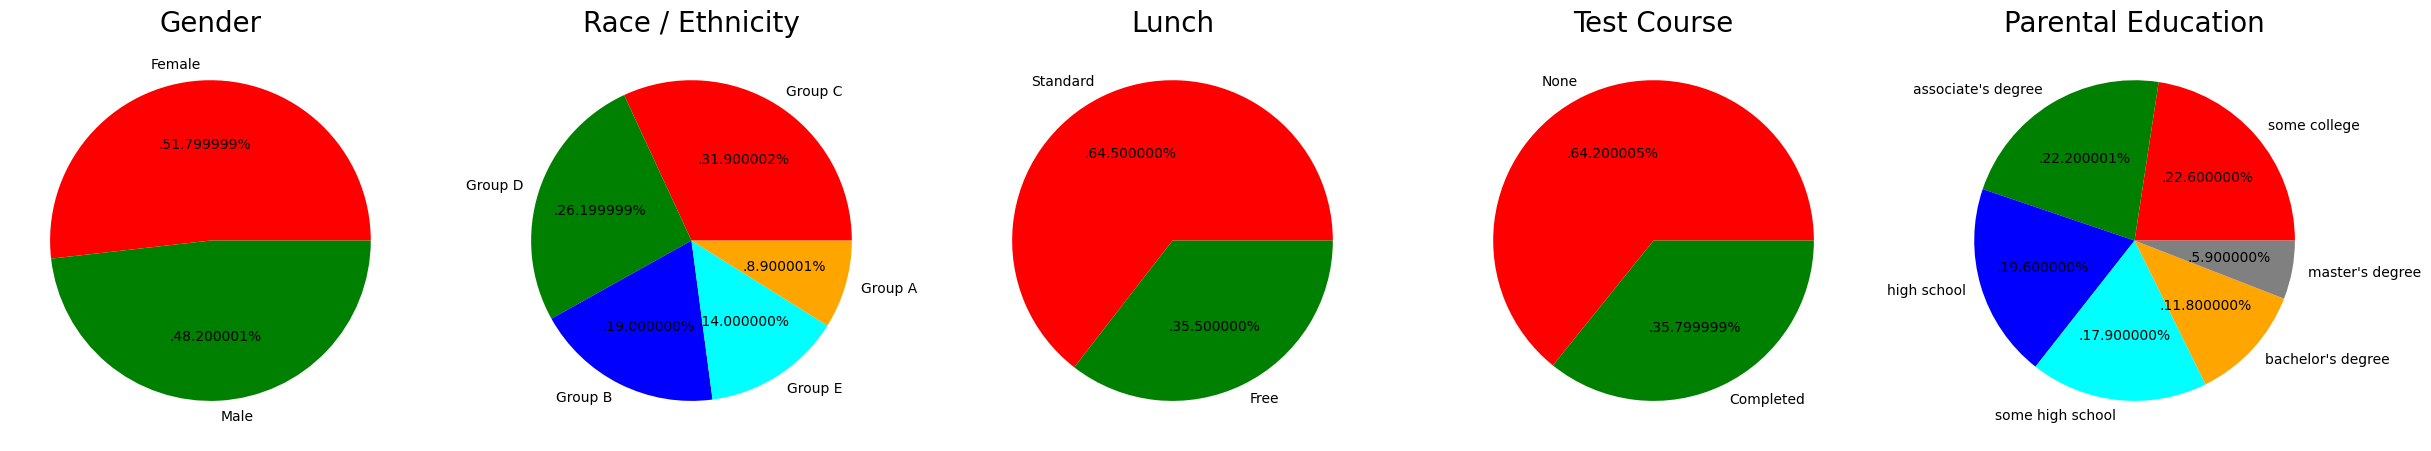

In [45]:
# Multivariate analysis

plt.rcParams['figure.figsize']= (30,10)

# 1 .
plt.subplot(1,5,1)
size = df['gender'].value_counts()
labels = 'Female','Male'
color = ['red', 'green']

plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%' )
plt.title('Gender',fontsize= 20)
plt.axis('off')

# 2 .
plt.subplot(1,5,2)
size  = df['race/ethnicity'].value_counts()
labels = 'Group C', 'Group D', 'Group B', 'Group E', 'Group A'
color = ['red' ,'green','blue', 'cyan', 'orange']

plt.pie(size,colors = color, labels = labels, autopct = '.%2f%%')
plt.title('Race / Ethnicity',fontsize = 20)
plt.axis('off')

# 3 .
plt.subplot(1,5,3)
size  = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red' ,'green']

plt.pie(size,colors = color, labels = labels, autopct = '.%2f%%')
plt.title('Lunch',fontsize = 20)
plt.axis('off')

# 4 .
plt.subplot(1,5,4)
size  = df['test preparation course'].value_counts()
labels = 'None', 'Completed'
color = ['red' ,'green']

plt.pie(size,colors = color, labels = labels, autopct = '.%2f%%')
plt.title('Test Course',fontsize = 20)
plt.axis('off')

# 5 .
plt.subplot(1,5,5)
size  = df['parental level of education'].value_counts()
labels = "some college","associate's degree","high school","some high school" ,"bachelor's degree","master's degree" 
color = ['red' ,'green','blue', 'cyan', 'orange','grey']

plt.pie(size,colors = color, labels = labels, autopct = '.%2f%%')
plt.title('Parental Education',fontsize = 20)
plt.axis('off')

### Insights :

Number of male and female students are almost equal

Number of students in are most in Group C 

Number of students having Standard lunch are greater than ones having free lunch

Number of students that have not enrolled in any course are greater 

Number of students whose parental education is "some college" is greatest followed closely by "associate's degree"

## Feature Wise Visualization

([<matplotlib.patches.Wedge at 0x7f4ddec39e50>,
 [Text(-0.062170487413935493, 1.0982416994881927, 'Male'),
  Text(0.06782216900078375, -1.1980818642279956, 'Female')],
 [Text(-0.03391117495305572, 0.5990409269935596, '51.8%'),
  Text(0.039562931917123845, -0.6988810874663307, '48.2%')])

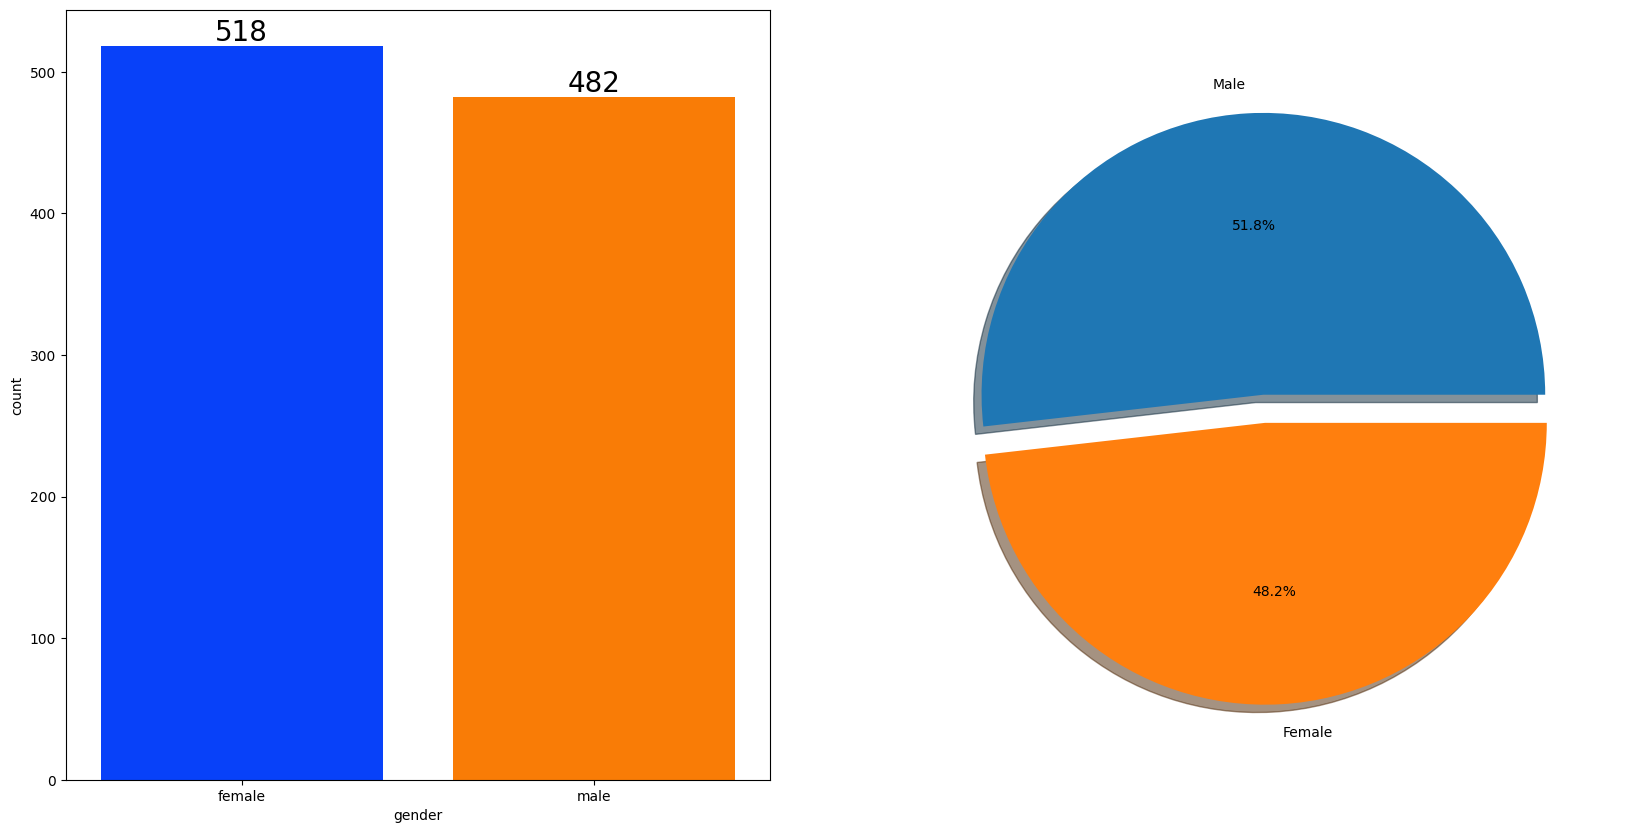

In [46]:
f,ax = plt.subplots(1,2, figsize  = (20,10))
sns.countplot(x = df['gender'],data = df , palette = 'bright', ax  = ax[0],saturation = 0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color = 'black',size= 20)

plt.pie(x = df['gender'].value_counts(), labels = ['Male','Female'],explode = [0,0.1], autopct = "%1.1f%%",shadow = True)

In [54]:
gender_group = df.groupby('gender').mean(numeric_only = True)
gender_group

,math score,reading score,writing score,total score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


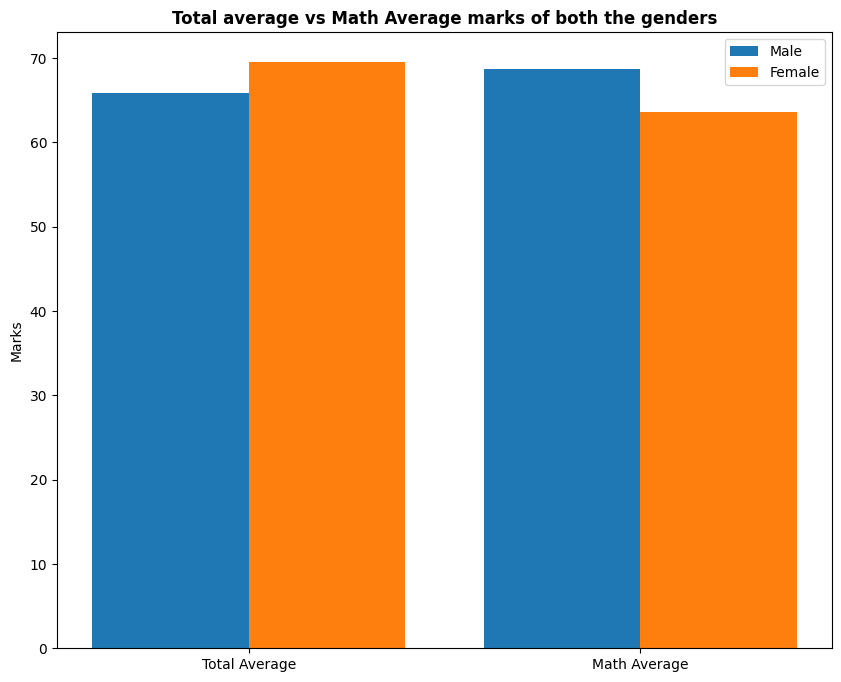

In [57]:
plt.figure(figsize = (10,8))

x = ['Total Average','Math Average']

female_scores = [gender_group['average']['female'],gender_group['math score']['female'] ]
male_scores = [gender_group['average']['male'], gender_group['math score']['male'] ]

x_axis = np.arange(len(x))

plt.bar(x_axis - 0.2 , male_scores , 0.4, label = 'Male')
plt.bar(x_axis + 0.2 , female_scores , 0.4, label = 'Female')

plt.xticks(x_axis,x)
plt.ylabel("Marks")
plt.title("Total average vs Math Average marks of both the genders", fontweight = 'bold')
plt.legend()

([<matplotlib.patches.Wedge at 0x7f4dd7677c50>,
 [Text(0.6461720141062023, 1.0111684964366394, 'group C'),
  Text(-1.0461621541481756, 0.33991873621212615, 'group D'),
  Text(-0.49322161839826323, -0.9832255260847321, 'group B'),
  Text(0.5952332509117035, -0.9250391218803047, 'group E'),
  Text(1.0572819245745813, -0.30357030811307883, 'group A')],
 [Text(0.3769336748952847, 0.5898482895880396, '31.9%'),
  Text(-0.5706339022626412, 0.1854102197520688, '26.2%'),
  Text(-0.2690299736717799, -0.5363048324098538, '19.0%'),
  Text(0.3246726823154746, -0.5045667937528934, '14.0%'),
  Text(0.5766992315861351, -0.16558380442531573, '8.9%')])

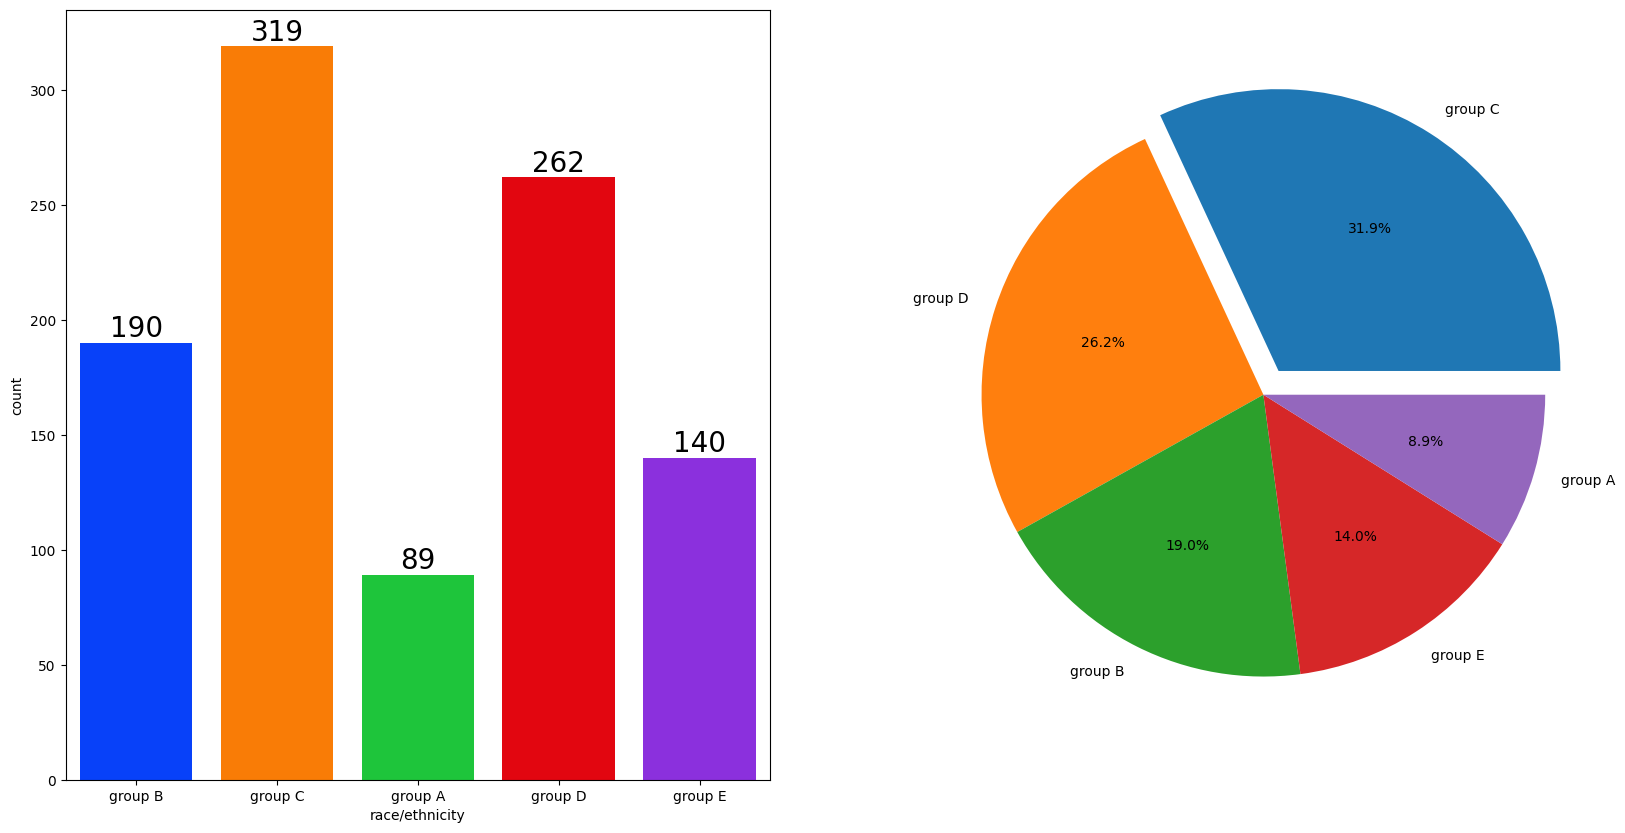

In [58]:
f,ax = plt.subplots(1,2,figsize = (20,10))
sns.countplot(x = df['race/ethnicity'],data = df,palette = 'bright',ax = ax[0], saturation = 0.95)
for container in ax[0].containers :
    ax[0].bar_label(container,color = 'black', size = 20)

ax[1].pie(x = df['race/ethnicity'].value_counts(), labels = df['race/ethnicity'].value_counts().index,explode = [0.1,0,0,0,0], autopct = '%1.1f%%')

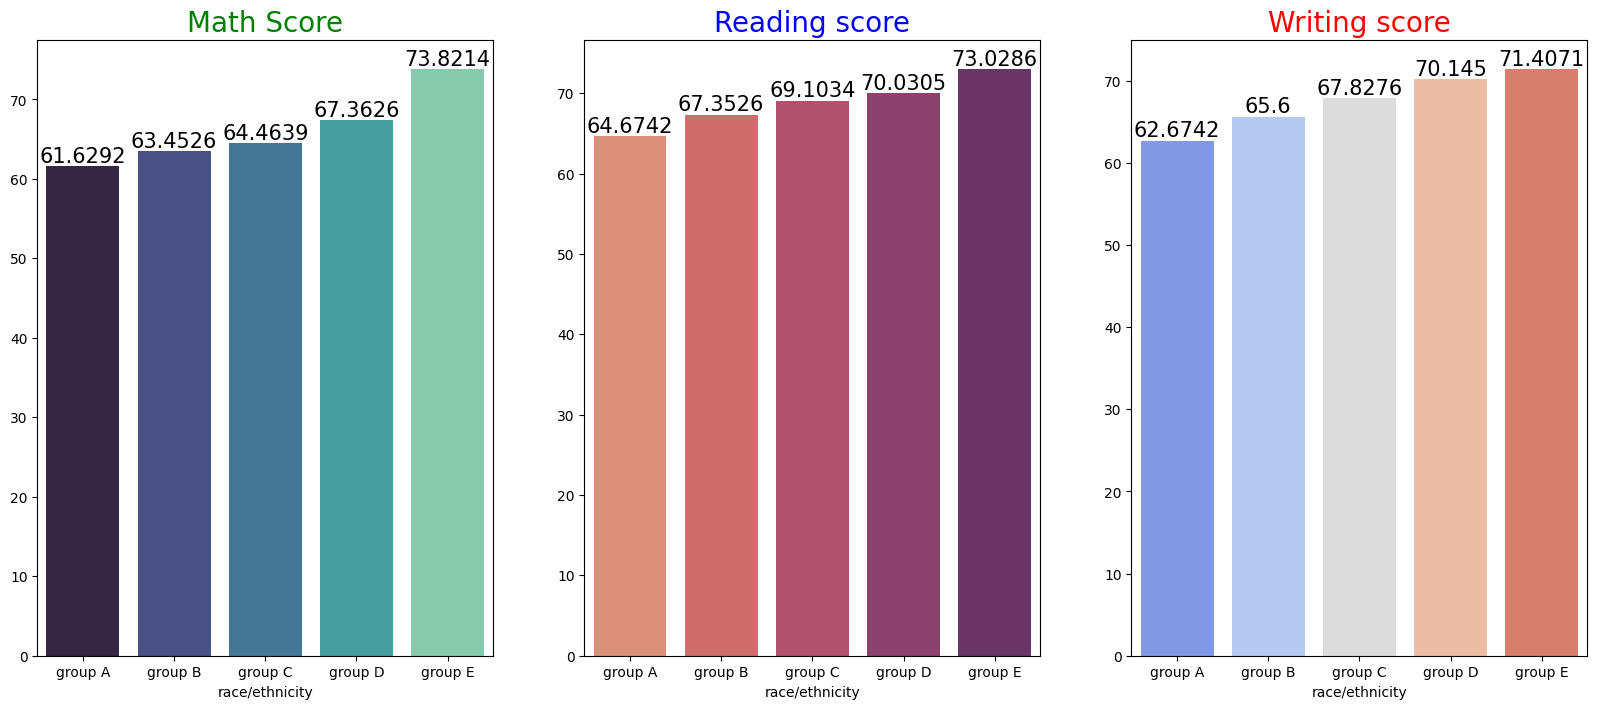

In [61]:
Group_data2 = df.groupby('race/ethnicity')
f, ax = plt.subplots(1,3,figsize = (20,8))

sns.barplot(x = Group_data2['math score'].mean().index, y = Group_data2['math score'].mean().values,palette = 'mako',ax = ax[0])
ax[0].set_title('Math Score',color = 'green',size = 20)

for container in ax[0].containers :
    ax[0].bar_label(container,color = 'black',size=15)

sns.barplot(x = Group_data2['reading score'].mean().index, y= Group_data2['reading score'].mean().values,palette = 'flare',ax = ax[1])
ax[1].set_title('Reading score', color ='blue', size = 20)

for container in ax[1].containers:
    ax[1].bar_label(container,color = 'black',size=15)

sns.barplot(x = Group_data2['writing score'].mean().index, y= Group_data2['writing score'].mean().values,palette = 'coolwarm',ax = ax[2])
ax[2].set_title('Writing score',color = 'red',size = 20)

for container in ax[2].containers:
    ax[2].bar_label(container, color= 'black',size =15)
    

Text(0, 0.5, 'Count')

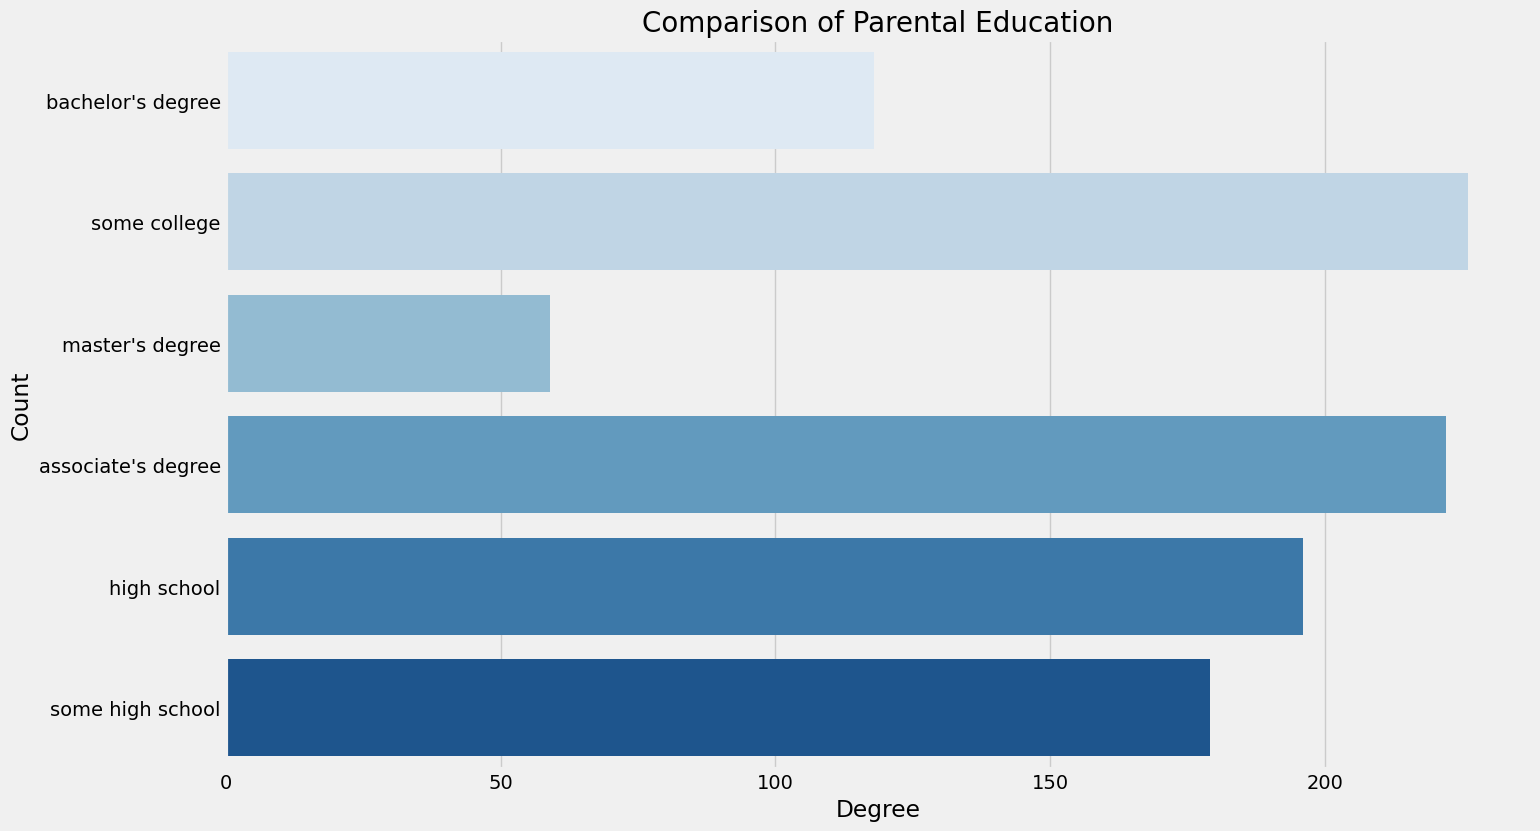

In [70]:
plt.rcParams['figure.figsize']=(15,9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental level of education'], palette = 'Blues')
plt.title('Comparison of Parental Education',fontweight = 30, fontsize = 20)
plt.xlabel ('Degree')
plt.ylabel('Count')


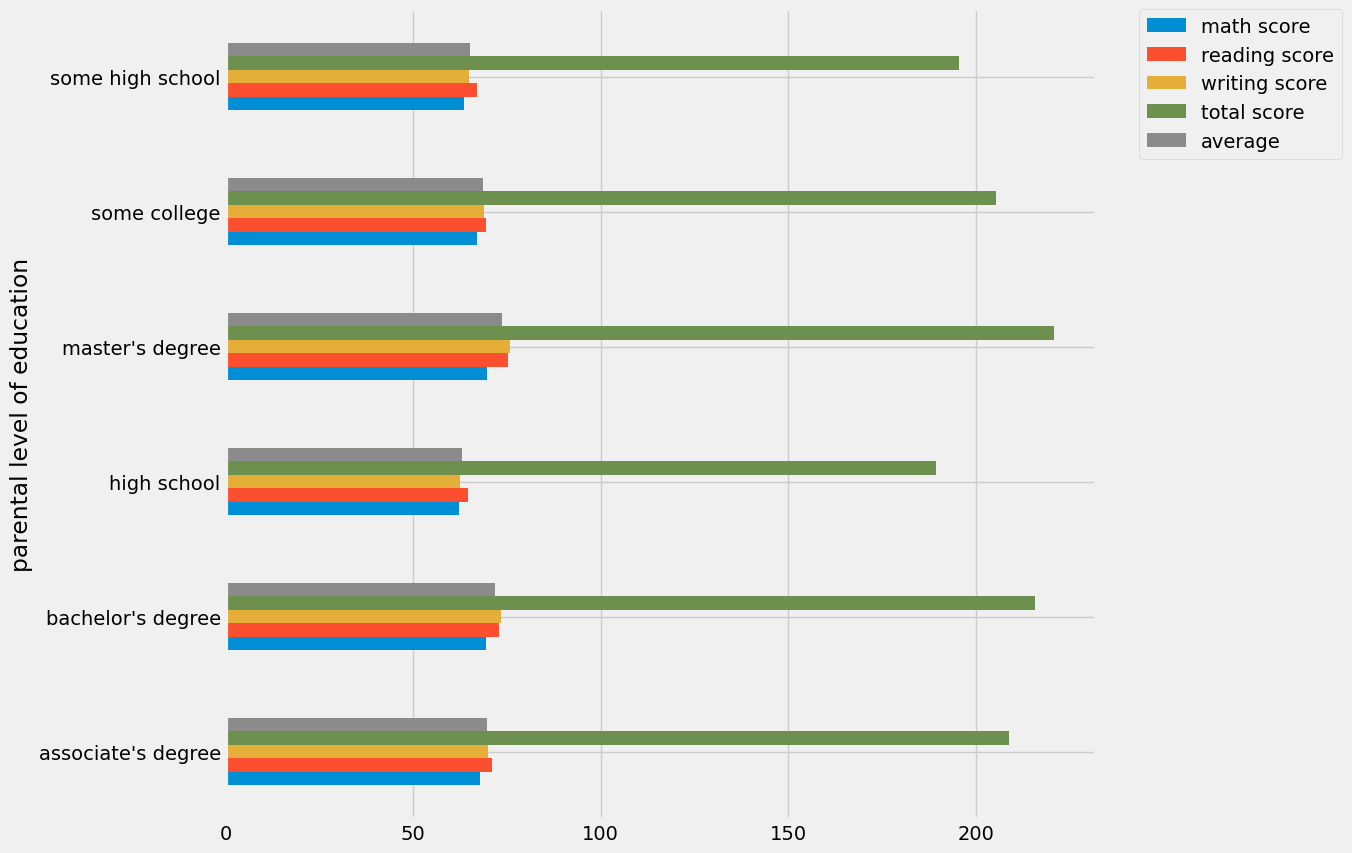

In [72]:
df.groupby('parental level of education').mean(numeric_only = True).plot(kind = 'barh',figsize = (10,10))
plt.legend(bbox_to_anchor = (1.05,1),loc = 'upper left', borderaxespad = 0.)

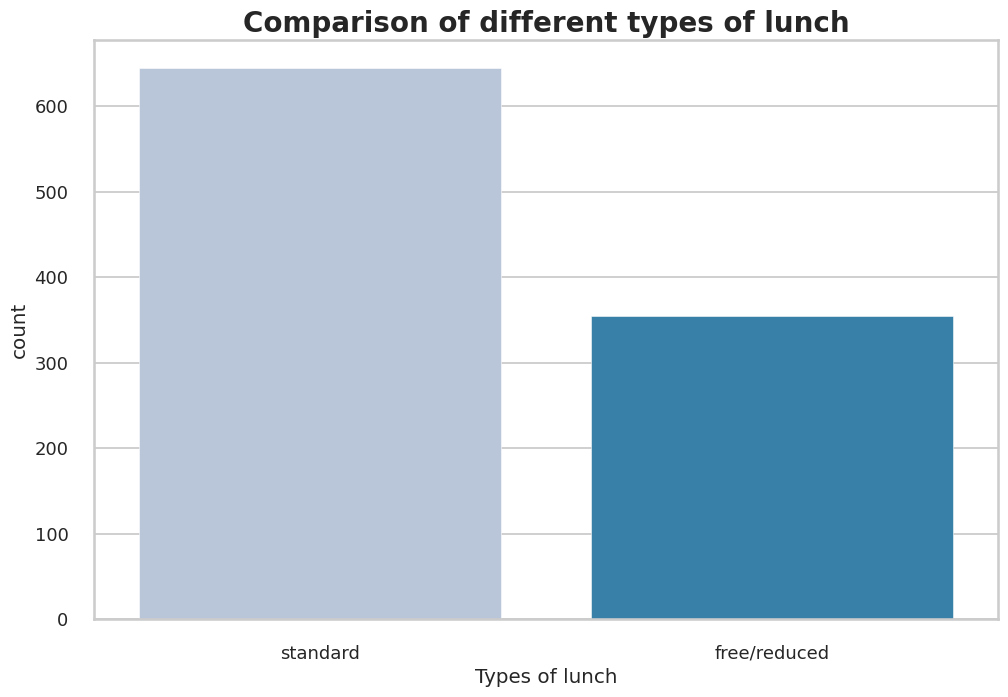

In [79]:
plt.rcParams['figure.figsize'] = (15,9)
plt.style.use('seaborn-v0_8-talk')
sns.countplot(x = 'lunch',data = df,palette = 'PuBu')
plt.title('Comparison of different types of lunch',fontweight = 'bold' , fontsize = 20)
plt.xlabel ("Types of lunch")
plt.ylabel('count')

sns.set_context('talk')
sns.set_style('whitegrid')

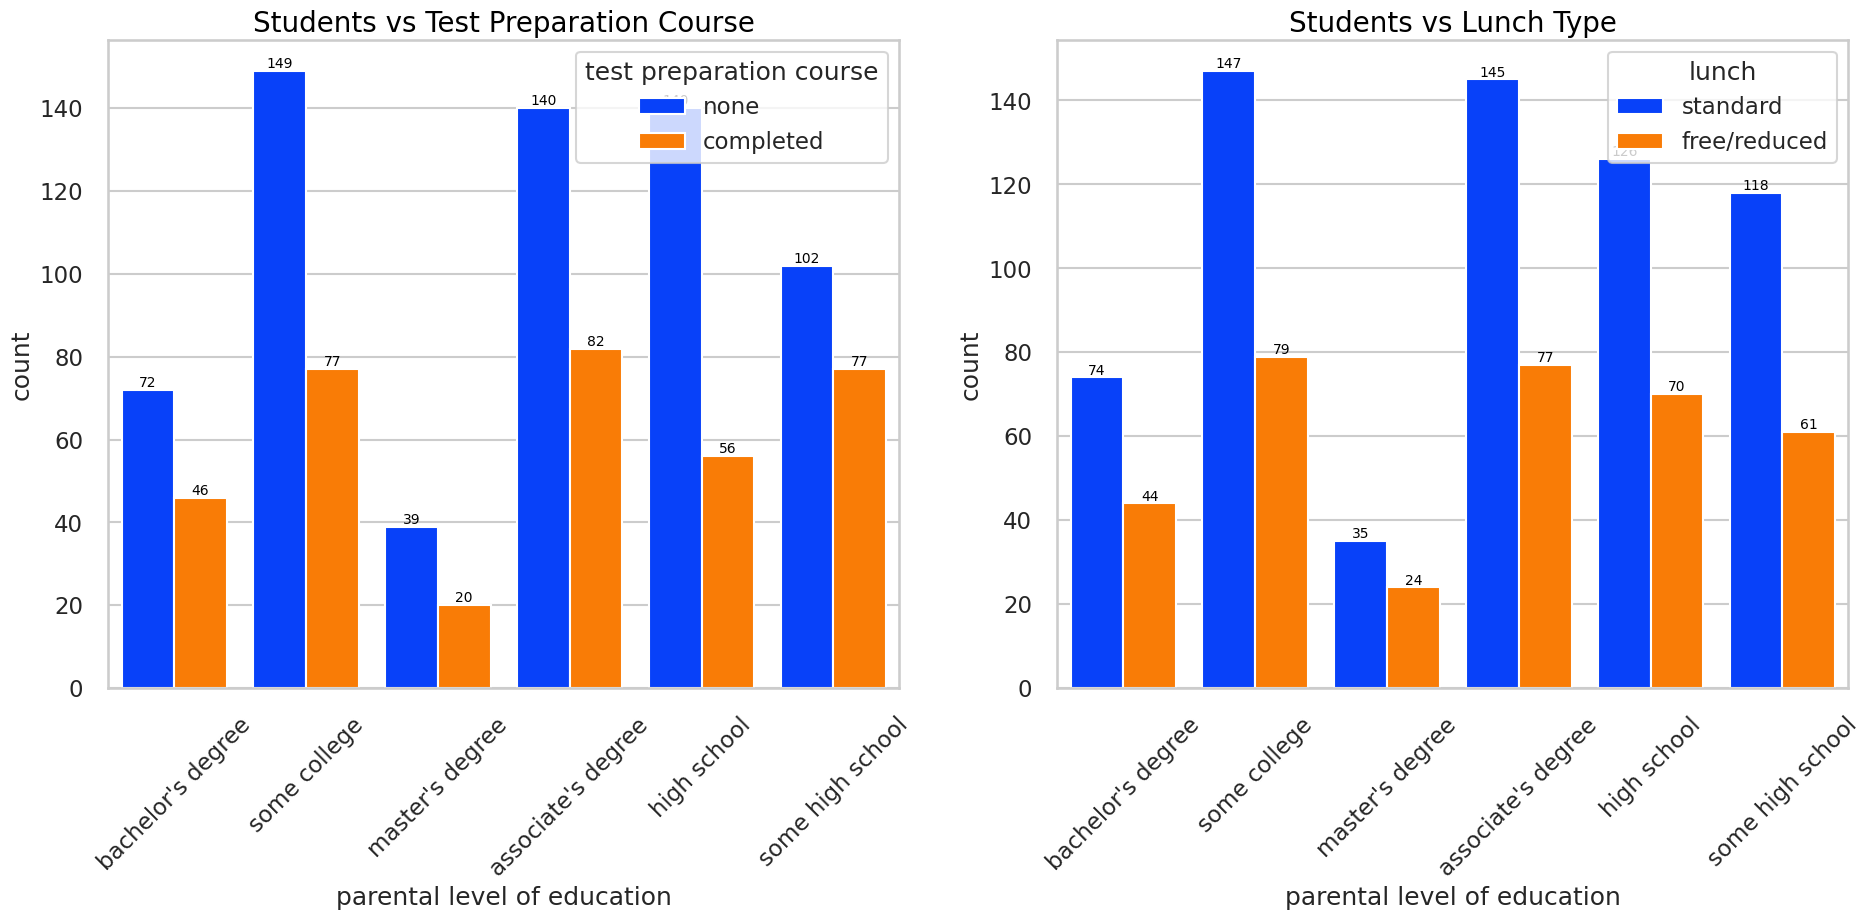

In [83]:
f, ax = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Test preparation course vs parental education
sns.countplot(
    x='parental level of education',
    data=df,
    palette='bright',
    hue='test preparation course',
    saturation=0.95,
    ax=ax[0]
)

ax[0].set_title('Students vs Test Preparation Course', color='black', size=20)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=10)

ax[0].tick_params(axis='x', rotation=45)


# Plot 2: Lunch vs parental education
sns.countplot(
    x='parental level of education',
    data=df,
    palette='bright',
    hue='lunch',
    saturation=0.95,
    ax=ax[1]
)

ax[1].set_title('Students vs Lunch Type', color='black', size=20)

for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=10)

ax[1].tick_params(axis='x', rotation=45)


<Axes: xlabel='lunch', ylabel='writing score'>

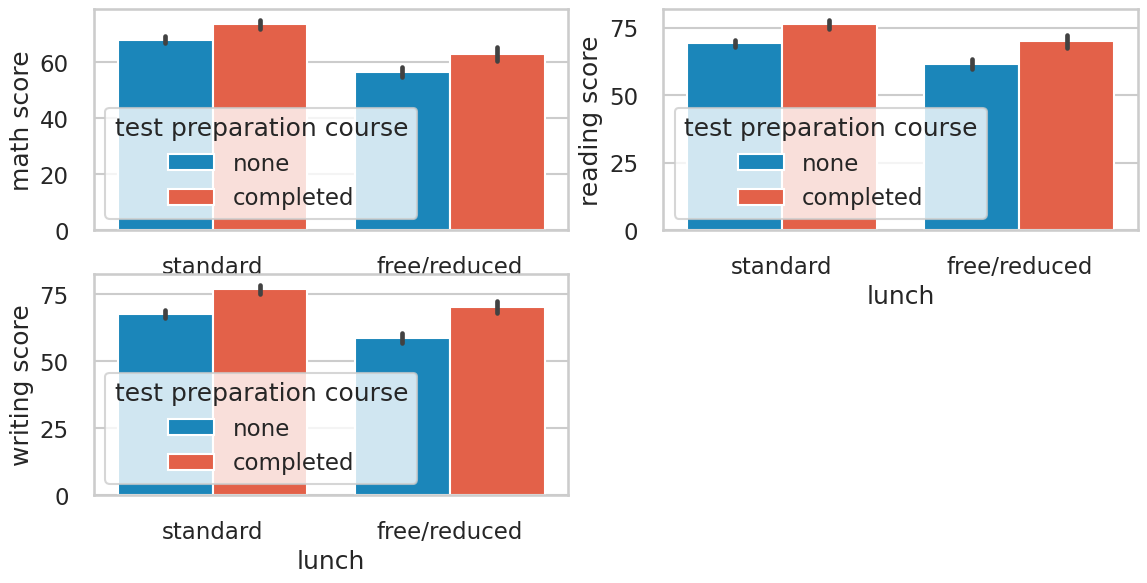

In [84]:
plt.figure(figsize=(12,6))

# Math score
plt.subplot(2,2,1)
sns.barplot(x='lunch', y='math score', hue='test preparation course', data=df)

# Reading score
plt.subplot(2,2,2)
sns.barplot(x='lunch', y='reading score', hue='test preparation course', data=df)

# Writing score
plt.subplot(2,2,3)
sns.barplot(x='lunch', y='writing score', hue='test preparation course', data=df)


<Axes: xlabel='average'>

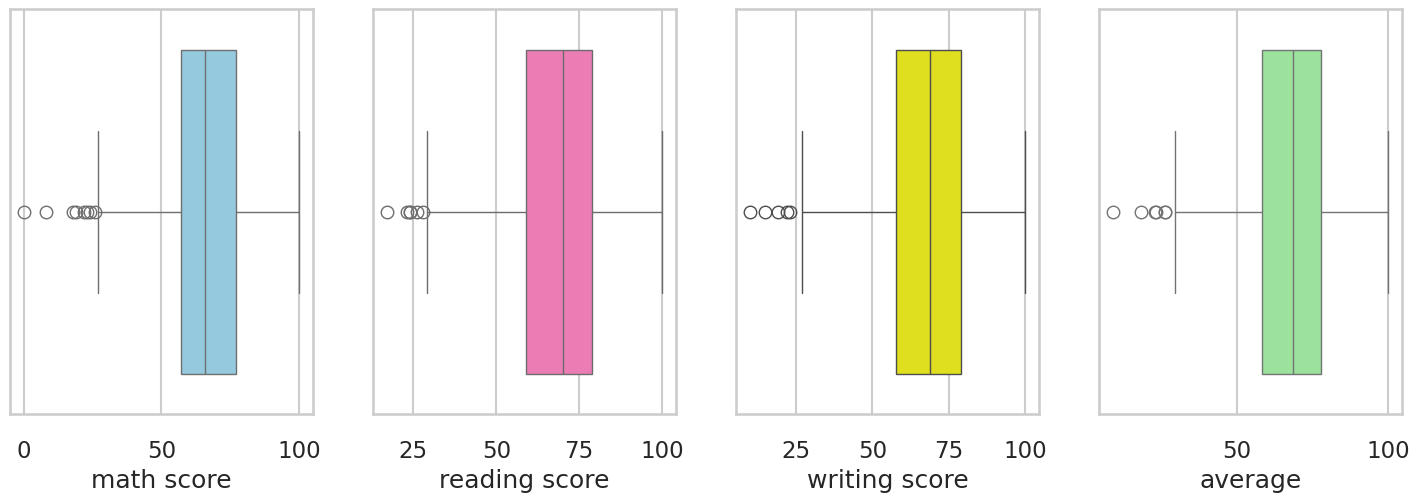

In [85]:
plt.figure(figsize=(16,5))

plt.subplot(1,4,1)
sns.boxplot(x=df['math score'], color='skyblue')

plt.subplot(1,4,2)
sns.boxplot(x=df['reading score'], color='hotpink')

plt.subplot(1,4,3)
sns.boxplot(x=df['writing score'], color='yellow')

plt.subplot(1,4,4)
sns.boxplot(x=df['average'], color='lightgreen')


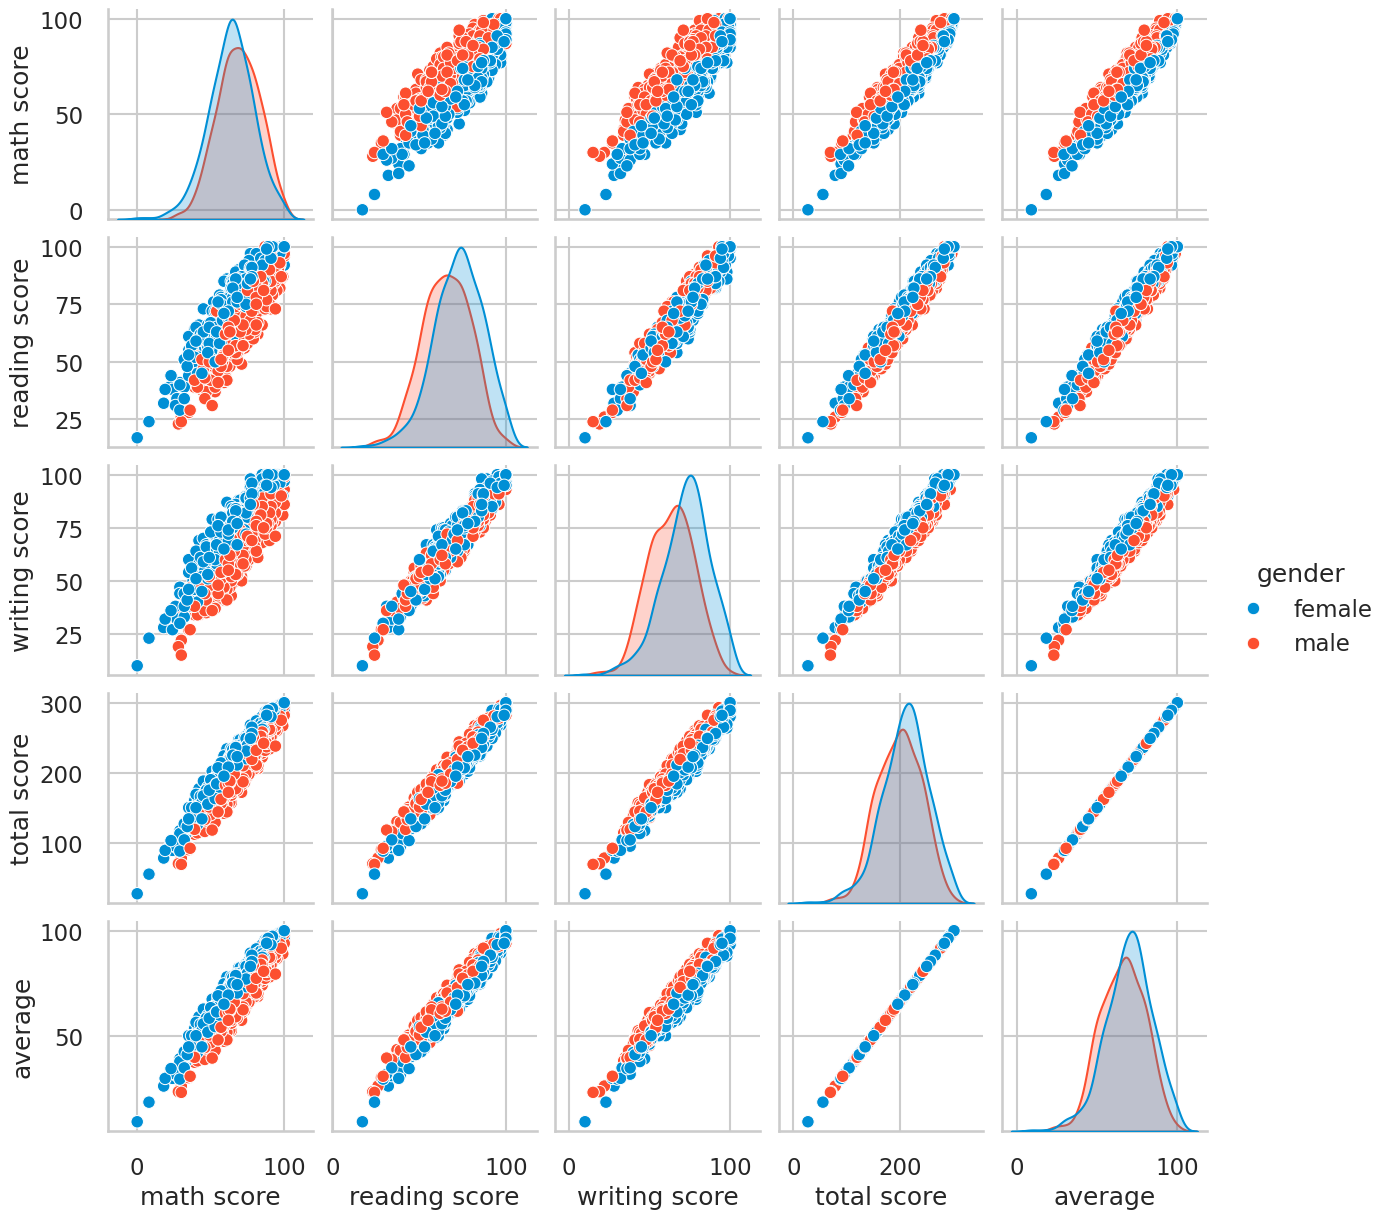

In [86]:
sns.pairplot(df,hue = 'gender')
